In [2]:
import numpy as np
import pandas as pd



In [3]:
pip show imbalanced-learn


Name: imbalanced-learn
Version: 0.14.1
Summary: Toolbox for imbalanced dataset in machine learning
Home-page: https://imbalanced-learn.org/
Author: 
Author-email: "G. Lemaitre" <g.lemaitre58@gmail.com>, "C. Aridas" <ichkoar@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scikit-learn, scipy, sklearn-compat, threadpoolctl
Required-by: 


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('creditcard.csv')

In [6]:
pd.options.display.max_columns = None

# 1. Display Top 5 Rows of The Dataset

In [7]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2. Check Last 5 Rows of The Dataset

In [8]:
data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


# 3. Find Shape of Our Dataset (Number of Rows And Number of Columns)

In [9]:
data.shape

(284807, 31)

In [10]:
print("Number of Rows",data.shape[0])
print("Number of Columns",data.shape[1])

Number of Rows 284807
Number of Columns 31


# 4. Get Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# 5. Check Null Values In The Dataset

In [12]:
data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


# Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
sc = StandardScaler()
data['Amount']=sc.fit_transform(pd.DataFrame(data['Amount']))

In [15]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [16]:
data = data.drop(['Time'],axis=1)

In [17]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [18]:
data.shape

(284807, 30)

In [19]:
data.duplicated().any()

np.True_

# Let's Remove Duplicated Values

In [20]:
data = data.drop_duplicates()

In [21]:
data.shape

(275663, 30)

In [22]:
284807- 275663

9144

# 6. Not Handling Imbalanced

In [23]:
data['Class'].value_counts()

,count
Class,
0,275190
1,473


In [24]:
import seaborn as sns

In [25]:
print(data['Class'].value_counts())

Class
0    275190
1       473
Name: count, dtype: int64


# 7. Store Feature Matrix In X And Response (Target) In Vector y

In [26]:
X = data.drop('Class',axis=1)
y = data['Class']

# 8. Splitting The Dataset Into The Training Set And Test Set

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,
                                                 random_state=42)

# 9. Handling Imbalanced Dataset

# Undersampling

In [28]:
normal = data[data['Class']==0]
fraud = data[data['Class']==1]

In [29]:
normal.shape

(275190, 30)

In [30]:
fraud.shape

(473, 30)

In [31]:
normal_sample=normal.sample(n=473)

In [32]:
normal_sample.shape

(473, 30)

In [33]:
new_data = pd.concat([normal_sample,fraud],ignore_index=True)

In [34]:
new_data['Class'].value_counts()

,count
Class,
0,473
1,473


In [35]:
new_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.877976,-0.481116,-0.319839,0.528923,-0.678114,-0.481882,-0.425560,-0.154691,1.247827,-0.234930,-0.864867,1.230659,1.637555,-0.490005,0.328409,0.053148,-0.634012,0.072690,-0.206400,-0.007780,0.235360,0.883978,0.033799,-0.041426,-0.047662,-0.217019,0.040714,-0.024799,-0.089596,0
1,-1.978146,2.646350,-2.315293,-1.693494,0.998282,-1.103239,1.236223,0.153035,0.985648,1.661915,-1.624662,-0.422459,-0.480341,0.470141,0.046041,-0.476200,-0.602633,-0.143433,-0.053281,0.781891,-0.036593,0.576928,-0.181863,0.042648,0.151830,0.079429,0.541984,0.118671,-0.350151,0
2,-1.831262,-0.596001,1.014637,-0.280475,1.953382,1.057463,1.399438,-1.058081,1.281961,1.744575,0.226288,0.132358,0.422361,-1.562787,-0.416914,-0.327581,-1.217352,-0.235951,1.065465,-0.361951,-0.779821,-0.188158,-0.001634,-1.648279,0.257264,0.216194,-0.864229,-0.832933,-0.079960,0
3,-1.007715,0.983054,0.650372,-1.154291,0.759909,-1.108217,1.332832,-0.441846,0.396946,0.043691,-1.120095,-0.445804,-0.798007,-0.110528,-0.522246,0.024934,-0.717350,-0.708889,-0.466510,-0.023420,-0.362132,-0.701364,-0.056073,-0.137965,-0.172569,0.071554,-0.002547,0.020965,-0.317287,0
4,-1.449484,1.448642,1.138391,-1.770210,-0.024510,-0.606763,0.789168,-0.256214,1.264064,1.681007,1.242629,0.324424,-0.253018,-0.738625,0.012680,0.631787,-1.341736,0.099507,-0.487322,0.840268,-0.390044,-0.235795,-0.115276,0.017997,-0.070618,0.637748,-0.084499,-0.598937,-0.350151,0


In [36]:
X = new_data.drop('Class',axis=1)
y = new_data['Class']

In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,
                                                 random_state=42)

# 10. Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [39]:
y_pred1 = log.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy_score(y_test,y_pred1)

0.9368421052631579

In [42]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [43]:
precision_score(y_test,y_pred1)

0.96875

In [44]:
recall_score(y_test,y_pred1)

0.9117647058823529

In [45]:
f1_score(y_test,y_pred1)

0.9393939393939394

# 11. Decision Tree Classifier

In [46]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [47]:
y_pred2 = dt.predict(X_test)

In [48]:
accuracy_score(y_test,y_pred2)

0.8789473684210526

In [49]:
precision_score(y_test,y_pred2)

0.8761904761904762

In [50]:
recall_score(y_test,y_pred2)

0.9019607843137255

In [51]:
f1_score(y_test,y_pred2)

0.8888888888888888

# 12. Random Forest Classifier

In [52]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [53]:
y_pred3 = rf.predict(X_test)

In [54]:
accuracy_score(y_test,y_pred3)

0.9315789473684211

In [55]:
precision_score(y_test,y_pred3)

0.968421052631579

In [56]:
recall_score(y_test,y_pred3)

0.9019607843137255

In [57]:
f1_score(y_test,y_pred3)

0.934010152284264

In [58]:
final_data = pd.DataFrame({'Models':['LR','DT','RF'],
              "ACC":[accuracy_score(y_test,y_pred1)*100,
                     accuracy_score(y_test,y_pred2)*100,
                     accuracy_score(y_test,y_pred3)*100
                    ]})

In [59]:
final_data

,Models,ACC
0,LR,93.684211
1,DT,87.894737
2,RF,93.157895


<Axes: xlabel='Models', ylabel='ACC'>

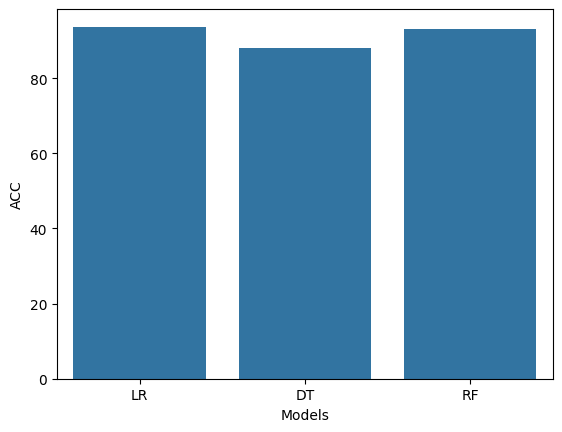

In [60]:
sns.barplot(data=final_data, x='Models', y='ACC')

# Oversampling

In [61]:
X = data.drop('Class',axis=1)
y = data['Class']

In [62]:
X.shape

(275663, 29)

In [63]:
y.shape

(275663,)

In [64]:
from imblearn.over_sampling import SMOTE

In [65]:
X_res,y_res = SMOTE().fit_resample(X,y)

In [66]:
y_res.value_counts()

,count
Class,
0,275190
1,275190


In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_res,y_res,test_size=0.20,
                                                 random_state=42)

# 10. Logistic Regression

In [68]:
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [69]:
y_pred1 = log.predict(X_test)

In [70]:
accuracy_score(y_test,y_pred1)

0.943784294487445

In [71]:
precision_score(y_test,y_pred1)

0.9731511098187458

In [72]:
recall_score(y_test,y_pred1)

0.9126774903187099

In [73]:
f1_score(y_test,y_pred1)

0.9419446842046009

# 11. Decision Tree Classifier

In [74]:
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [75]:
y_pred2 = dt.predict(X_test)

In [76]:
accuracy_score(y_test,y_pred2)

0.9983465968966896

In [77]:
precision_score(y_test,y_pred2)

0.9976579095481036

In [78]:
recall_score(y_test,y_pred2)

0.9990364161954802

In [79]:
f1_score(y_test,y_pred2)

0.9983466870151342

# 12. Random Forest Classifier

In [80]:
rf = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [81]:
y_pred3 = rf.predict(X_test)

In [82]:
accuracy_score(y_test,y_pred3)

0.9999091536756423

In [83]:
precision_score(y_test,y_pred3)

0.999818224783233

In [84]:
recall_score(y_test,y_pred3)

1.0

In [85]:
f1_score(y_test,y_pred3)

0.9999091041303083

In [86]:
final_data = pd.DataFrame({'Models':['LR','DT','RF'],
              "ACC":[accuracy_score(y_test,y_pred1)*100,
                     accuracy_score(y_test,y_pred2)*100,
                     accuracy_score(y_test,y_pred3)*100
                    ]})

In [87]:
final_data

,Models,ACC
0,LR,94.378429
1,DT,99.834660
2,RF,99.990915


<Axes: xlabel='Models', ylabel='ACC'>

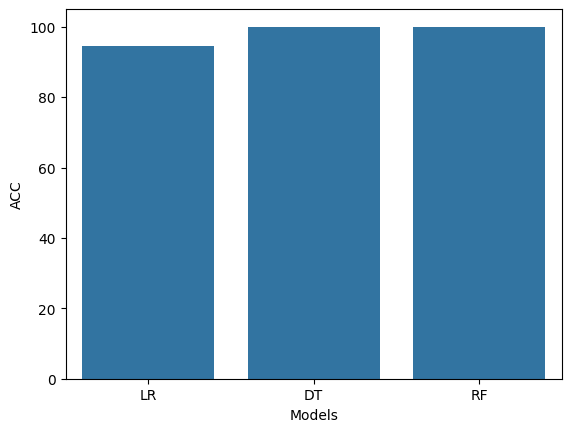

In [89]:
sns.barplot(data=final_data, x='Models', y='ACC')

# Save The Model

In [91]:
rf1 = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf1.fit(X_res, y_res)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [92]:
import joblib

In [ ]:
# Save the trained model
joblib.dump(rf, 'model_credit.pkl')
print("Model saved as model_credit.pkl")

# Predict on a single transaction
def predict_transaction(values):
    model = joblib.load('model_credit.pkl')
    y_pred = model.predict([values])
    print("######################################")
    if y_pred == 0:
        print("Result: Normal Transaction")
    else:
        print("Result: Fraudulent Transaction")
    print("######################################")

# Test with a sample from the test set
sample = X_test.iloc[0].tolist()
predict_transaction(sample)